<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/RC%20ECG%20forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time series forecasting

In [1]:
!pip install -qq -U reservoir_computing

In [2]:
import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from reservoir_computing.modules import RC_forecaster
from reservoir_computing.utils import make_forecasting_dataset
from reservoir_computing.datasets import PredLoader

np.random.seed(0) # For reproducibility

## Configure the RC model

In [3]:
config = {}

# Reservoir
config['n_internal_units'] = 900        # size of the reservoir
config['spectral_radius'] = 0.95        # largest eigenvalue of the reservoir
config['leak'] = None                   # amount of leakage in the reservoir state update (None or 1.0 --> no leakage)
config['connectivity'] = 0.25           # percentage of nonzero connections in the reservoir
config['input_scaling'] = 0.1           # scaling of the input weights
config['noise_level'] = 0.0             # noise in the reservoir state update
config['n_drop'] = 10                   # transient states to be dropped
config['circle'] = False                # use reservoir with circle topology

# Dimensionality reduction
config['dimred_method'] = 'pca'         # options: {None (no dimensionality reduction), 'pca'}
config['n_dim'] = 75                    # number of resulting dimensions after the dimensionality reduction procedure

# Linear readout
config['w_ridge'] = 1.0                 # regularization of the ridge regression readout

pprint.pprint(config)

{'circle': False,
 'connectivity': 0.25,
 'dimred_method': 'pca',
 'input_scaling': 0.1,
 'leak': None,
 'n_dim': 75,
 'n_drop': 10,
 'n_internal_units': 900,
 'noise_level': 0.0,
 'spectral_radius': 0.95,
 'w_ridge': 1.0}


## Example 1 - Prepare the vanilla data - Electricity consumptions of Rome

In [4]:
# Load the dataset
ts_full = PredLoader().get_data('ElecRome')

Loaded ElecRome dataset.
Data shape:
  X: (137376, 1)


In [5]:
# Resample the time series to hourly frequency
ts_hourly = np.mean(ts_full.reshape(-1, 6), axis=1)
print(ts_hourly.shape)

(22896,)


In [6]:
# Use only the first 3000 time steps
ts_small = ts_hourly[0:3000, None]
print(ts_small.shape)

(3000, 1)


In [7]:
# Generate training and testing datasets
Xtr, Ytr, Xte, Yte, scaler = make_forecasting_dataset(
    ts_small,
    horizon=24, # forecast horizon of 24h ahead
    test_percent = 0.1)

print(f"Xtr shape: {Xtr.shape}\nYtr shape: {Ytr.shape}\nXte shape: {Xte.shape}\nYte shape: {Yte.shape}")

Xtr shape: (2676, 2)
Ytr shape: (2676, 1)
Xte shape: (276, 2)
Yte shape: (276, 1)


# Example 2 - try to load ECG and prepare for predictions

In [13]:
import kagglehub

# Download latest version
file_path = kagglehub.dataset_download("denisandrikov/ecg-timeseries-for-prediction")

print("Path to dataset files:", path)

100%|██████████| 49.1k/49.1k [00:00<00:00, 25.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/denisandrikov/ecg-timeseries-for-prediction/versions/1


In [14]:
path

'/root/.cache/kagglehub/datasets/denisandrikov/ecg-timeseries-for-prediction/versions/1'

In [17]:
#https://www.kaggle.com/datasets/denisandrikov/ecg-timeseries-for-prediction

heart_beat_ts = pd.read_csv(file_path+'/ecg_1d_timeseries_prediction.csv',sep=';')

In [18]:
arr = np.array(heart_beat_ts['ecg_value'])
arr = arr.T
new_arr = [[x] for x in arr]
new_arr = np.array(new_arr)

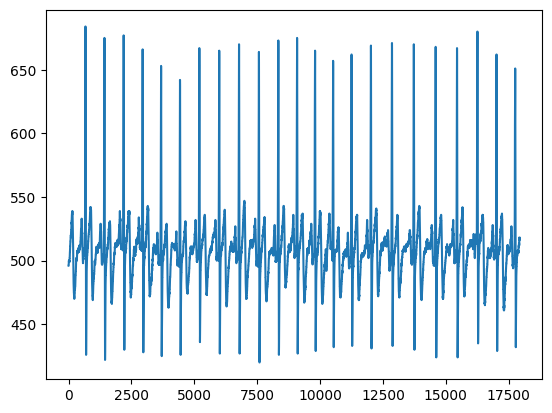

In [19]:
plt.plot(new_arr)

In [20]:
# Generate training and testing datasets
Xtr, Ytr, Xte, Yte, scaler = make_forecasting_dataset(
    new_arr,
    horizon=24, # forecast horizon of 24h ahead
    test_percent = 0.1)

print(f"Xtr shape: {Xtr.shape}\nYtr shape: {Ytr.shape}\nXte shape: {Xte.shape}\nYte shape: {Yte.shape}")

Xtr shape: (16117, 2)
Ytr shape: (16117, 1)
Xte shape: (1770, 2)
Yte shape: (1770, 1)


# Train the RC model and make predictions

In [21]:
# Initialize the RC model
forecaster =  RC_forecaster(**config)

In [22]:
# Train the model
forecaster.fit(Xtr, Ytr)

Training completed in 0.16 min


array([[-2.01518859e+00, -4.86524624e-01,  9.59090729e-02, ...,
         3.09074426e-03,  3.59132178e-05,  7.32655171e-03],
       [-2.08832228e+00, -4.22365423e-01, -5.10151699e-02, ...,
        -1.30285879e-02, -4.79578520e-04, -2.62959265e-02],
       [-2.12971990e+00, -3.98524559e-01, -1.75925564e-01, ...,
        -1.43307925e-02,  1.27744677e-02,  5.30651158e-02],
       ...,
       [ 2.39833433e+00,  8.94599626e-01, -5.00582566e-02, ...,
         1.83240532e-03,  2.88108335e-03,  3.89899471e-05],
       [ 2.32773328e+00,  9.33106655e-01, -2.26116203e-02, ...,
        -3.65603112e-04,  1.21817609e-03, -2.87402897e-03],
       [ 2.15460124e+00,  1.03242008e+00,  2.28103249e-02, ...,
         1.82324078e-03,  1.51644250e-03, -2.03138404e-03]])

In [23]:
# Compute predictions on test data
Yhat = forecaster.predict(Xte)
new_array = [[x] for x in Yhat]
Yhat = scaler.inverse_transform(new_array) # Revert the scaling of the predictions
mse = mean_squared_error(Yte[config['n_drop']:,:], Yhat)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 486.59


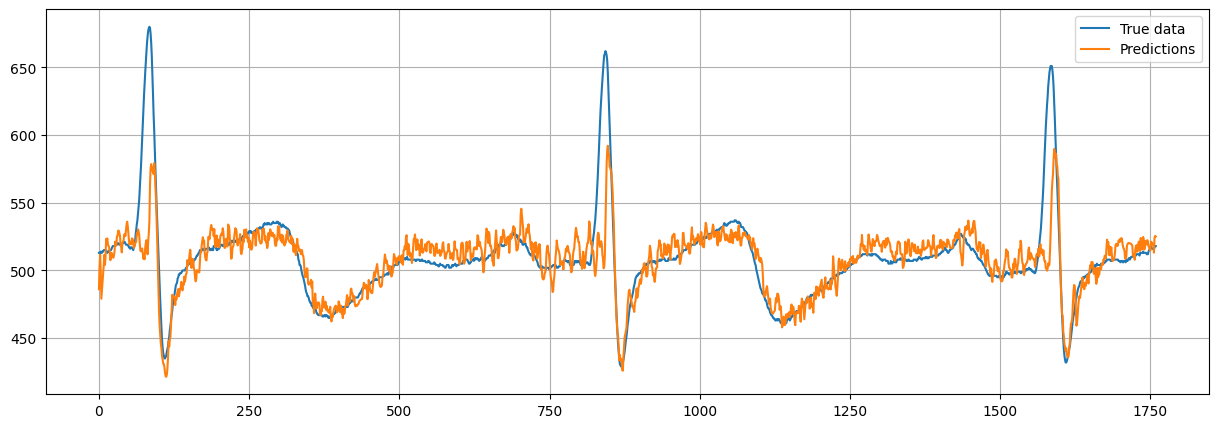

In [24]:
# Plot the predictions
plt.figure(figsize=(15, 5))
plt.plot(Yte[config['n_drop']:,:], label='True data')
plt.plot(Yhat, label='Predictions')
plt.legend()
plt.grid()
plt.show()